# Практика 22. Часовий ряд

**Студент:** Коць Артем  
**Група:** ІТ-42  
**Варіант:** 9  
**Місто:** Суми

## Мета роботи

Побудувати 10-річний щомісячний часовий ряд температури для міста
Суми, дослідити його за допомогою ковзного середнього, виконати
декомпозицію на тренд, сезонність і залишок, побудувати прогноз
на майбутні місяці та перевірити статистичну значущість тренду

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import linregress

## Завдання 1. Побудова багаторічного часового ряду

Для варіанта 9 використаємо параметри міста Суми:

- середньорічна температура — 7.5 °C;
- сезонна амплітуда — 14 °C;
- тренд потепління — 0.03 °C/рік;
- стандартне відхилення шуму — 0.9 °C.

Ряд містить 10 років або 120 щомісячних спостережень.

In [2]:
np.random.seed(9)

base_temp = 7.5
amplitude = 14
trend_per_year = 0.03
noise_scale = 0.9
city = "Суми"

n_years = 10

dates = pd.date_range(
    start="2015-01-01",
    periods=n_years * 12,
    freq="MS"
)

month = dates.month

years_elapsed = (
    (dates.year - dates.year[0])
    + (dates.month - 1) / 12
)

seasonal = amplitude * np.cos(
    (month - 7) / 12 * 2 * np.pi
)

trend = trend_per_year * years_elapsed

noise = np.random.normal(
    0,
    noise_scale,
    len(dates)
)

temp = np.round(
    base_temp + trend + seasonal + noise,
    1
)

climate_ts = pd.Series(
    temp,
    index=dates,
    name="температура"
)

print(climate_ts.head(12))
print("\nКількість спостережень:", len(climate_ts))

2015-01-01    -6.5
2015-02-01    -4.9
2015-03-01    -0.5
2015-04-01     7.5
2015-05-01    14.2
2015-06-01    19.2
2015-07-01    20.1
2015-08-01    19.2
2015-09-01    14.3
2015-10-01     6.9
2015-11-01     1.1
2015-12-01    -3.0
Freq: MS, Name: температура, dtype: float64

Кількість спостережень: 120


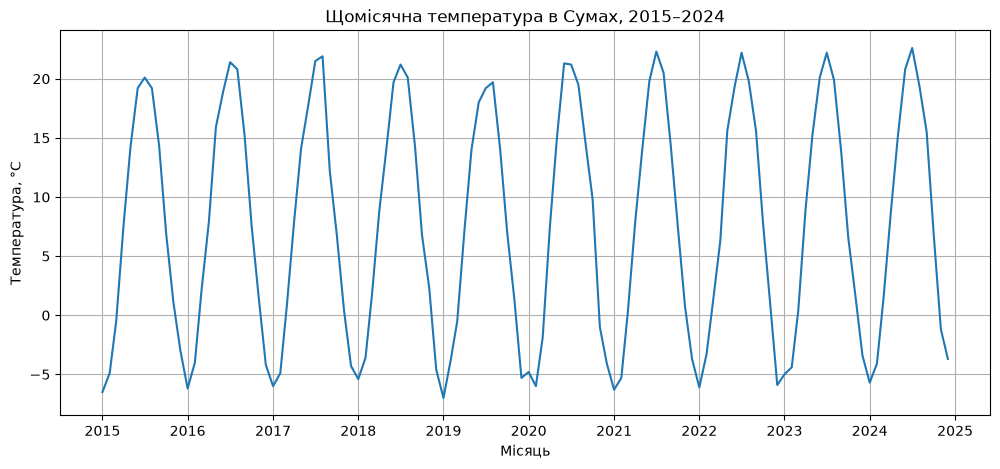

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    climate_ts.index,
    climate_ts.values
)

ax.set_xlabel("Місяць")
ax.set_ylabel("Температура, °C")
ax.set_title(
    "Щомісячна температура в Сумах, 2015–2024"
)
ax.grid(True)

plt.show()

### Опис графіка

На графіку чітко видно регулярні сезонні коливання температури
протягом кожного року. Найвищі значення припадають приблизно на
літні місяці, а найнижчі — на зимові.

Загальний тренд потепління є значно слабшим за сезонну складову,
оскільки він становить лише 0.03 °C на рік. За десять років
теоретичне збільшення рівня становить приблизно 0.3 °C.

Таким чином, у часовому ряді одночасно присутні сезонність,
повільний тренд і випадковий шум.

## Завдання 2. Ковзне середнє

Для дослідження впливу розміру вікна побудуємо центровані ковзні
середні з вікнами 3 та 12 місяців.

Вікно 3 місяці сильніше зберігає сезонні коливання, але прибирає
частину випадкового шуму.

Вікно 12 місяців відповідає повному сезонному циклу і тому краще
виділяє довгостроковий тренд.

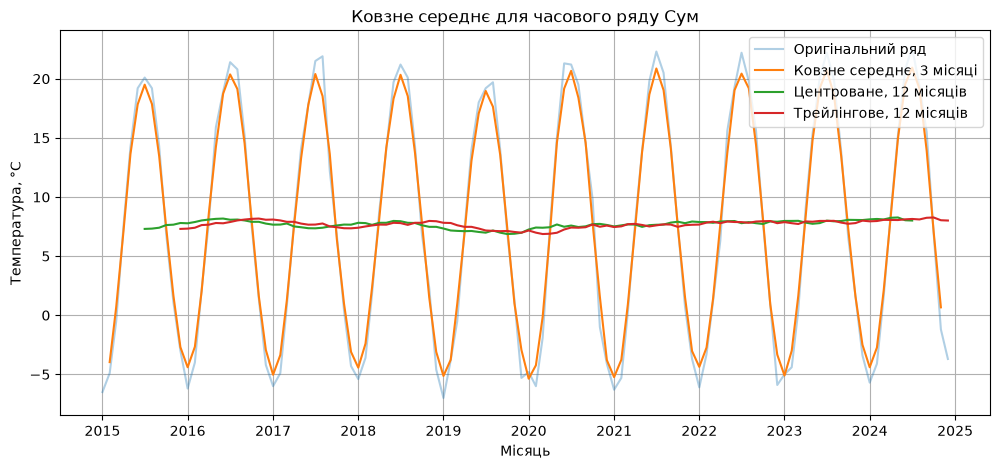

In [4]:
ma3 = climate_ts.rolling(
    window=3,
    center=True
).mean()

ma12 = climate_ts.rolling(
    window=12,
    center=True
).mean()

ma12_trailing = climate_ts.rolling(
    window=12
).mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    climate_ts.index,
    climate_ts.values,
    alpha=0.35,
    label="Оригінальний ряд"
)

ax.plot(
    climate_ts.index,
    ma3.values,
    label="Ковзне середнє, 3 місяці"
)

ax.plot(
    climate_ts.index,
    ma12.values,
    label="Центроване, 12 місяців"
)

ax.plot(
    climate_ts.index,
    ma12_trailing.values,
    label="Трейлінгове, 12 місяців"
)

ax.set_xlabel("Місяць")
ax.set_ylabel("Температура, °C")
ax.set_title("Ковзне середнє для часового ряду Сум")
ax.legend()
ax.grid(True)

plt.show()

### Аналіз ковзного середнього

Вікно 3 місяці зменшує випадковий шум, але сезонна хвиля залишається
помітною.

Вікно 12 місяців краще прибирає сезонну складову, оскільки один рік
містить повний сезонний цикл. Тому таке вікно дає більш плавну
оцінку довгострокового тренду.

Центроване 12-місячне середнє використовує спостереження як до,
так і після поточного місяця. Тому воно краще відображає рівень
ряду в конкретний момент часу.

Трейлінгове середнє використовує тільки поточний і попередні
місяці. Через це зміни в часовому ряді відображаються із запізненням,
тобто виникає лаг.

Центроване середнє не можна повноцінно використовувати в реальному
часі, оскільки для його розрахунку потрібні майбутні спостереження.

## Завдання 3. Декомпозиція часового ряду

Виконаємо адитивну декомпозицію:

температура = тренд + сезонність + залишок.

Оскільки сезонний цикл дорівнює одному року, використовуємо
`period=12`.

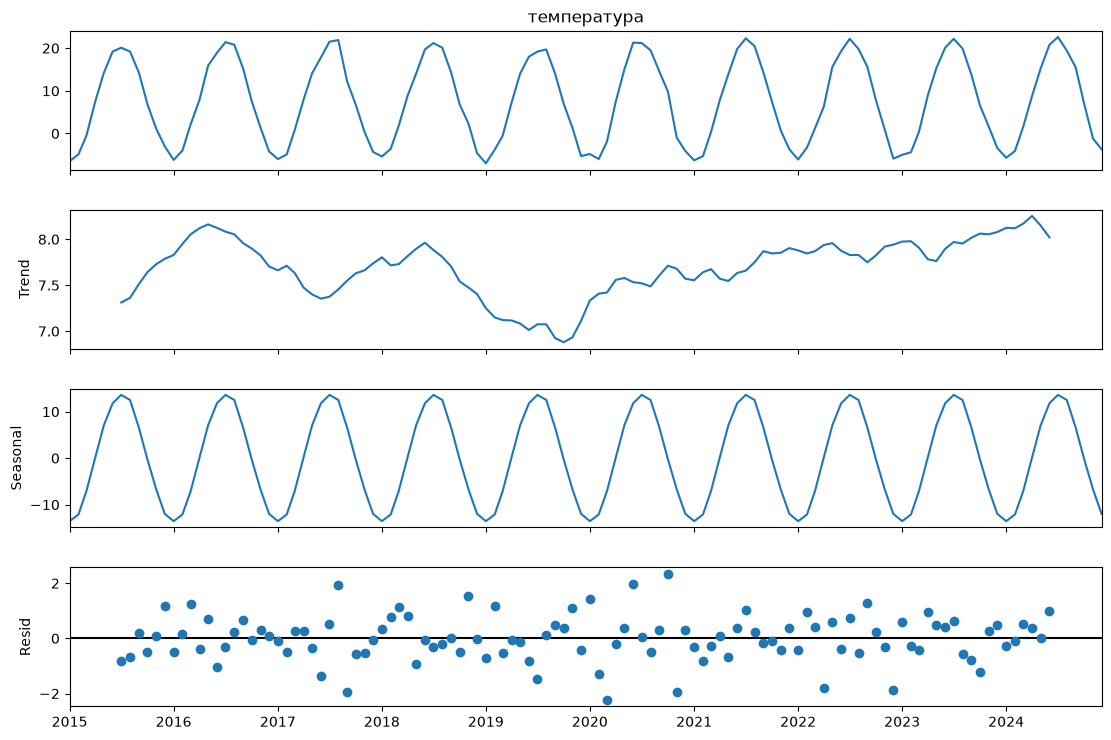

In [5]:
decomposition = seasonal_decompose(
    climate_ts,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.show()

In [6]:
trend_component = decomposition.trend.dropna()
seasonal_component = decomposition.seasonal
resid_component = decomposition.resid.dropna()

print("Діапазон тренду:")
print(
    f"{trend_component.min():.2f} ... "
    f"{trend_component.max():.2f} °C"
)

print("\nНайвищий сезонний ефект:")
print(
    seasonal_component.groupby(
        seasonal_component.index.month
    ).mean().idxmax()
)

print("\nНайнижчий сезонний ефект:")
print(
    seasonal_component.groupby(
        seasonal_component.index.month
    ).mean().idxmin()
)

print(
    "\nСтандартне відхилення залишку:",
    f"{resid_component.std():.2f} °C"
)

Діапазон тренду:
6.88 ... 8.25 °C

Найвищий сезонний ефект:
7

Найнижчий сезонний ефект:
1

Стандартне відхилення залишку: 0.83 °C


### Інтерпретація декомпозиції

Оцінений тренд має загалом висхідний характер, що відповідає
закладеному під час генерації тренду потепління 0.03 °C/рік.

Сезонна компонента має регулярний річний цикл. Найбільший додатний
сезонний ефект припадає приблизно на липень, а найменший — на
січень. Це відповідає формулі генерації з максимумом у середині
літа.

Залишкова компонента описує випадкові коливання, які не пояснюються
трендом і сезонністю. Її стандартне відхилення має бути близьким
до заданого під час генерації `noise_scale = 0.9 °C`, хоча точного
збігу очікувати не потрібно через випадковий характер шуму.

## Завдання 4. Прогноз на 12 місяців уперед

Для прогнозування використаємо очищений від сезонності тренд,
отриманий під час декомпозиції.

На трендовій компоненті побудуємо лінійну регресію, після чого
продовжимо її на 12 місяців. До отриманого тренду додамо типовий
сезонний ефект відповідного календарного місяця.

In [7]:
trend_clean = decomposition.trend.dropna()

x = np.arange(len(trend_clean))

fit = linregress(
    x,
    trend_clean.values
)

print(f"Нахил тренду: {fit.slope:.5f} °C/місяць")
print(f"Нахил за рік: {fit.slope * 12:.5f} °C/рік")
print(f"p-value: {fit.pvalue:.6g}")
print(f"stderr: {fit.stderr:.6f}")

Нахил тренду: 0.00297 °C/місяць
Нахил за рік: 0.03561 °C/рік
p-value: 0.00175388
stderr: 0.000924


In [8]:
n_ahead = 12

x_future = np.arange(
    len(trend_clean),
    len(trend_clean) + n_ahead
)

trend_forecast = (
    fit.intercept +
    fit.slope * x_future
)

seasonal_by_month = (
    decomposition.seasonal
    .groupby(decomposition.seasonal.index.month)
    .mean()
)

future_dates = pd.date_range(
    climate_ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=n_ahead,
    freq="MS"
)

seasonal_forecast = seasonal_by_month.reindex(
    future_dates.month
).values

forecast = pd.Series(
    trend_forecast + seasonal_forecast,
    index=future_dates,
    name="прогноз"
)

print(forecast.round(1))

2025-01-01    -5.7
2025-02-01    -4.3
2025-03-01     0.8
2025-04-01     8.0
2025-05-01    14.9
2025-06-01    19.7
2025-07-01    21.5
2025-08-01    20.4
2025-09-01    14.5
2025-10-01     7.6
2025-11-01     1.2
2025-12-01    -4.1
Freq: MS, Name: прогноз, dtype: float64


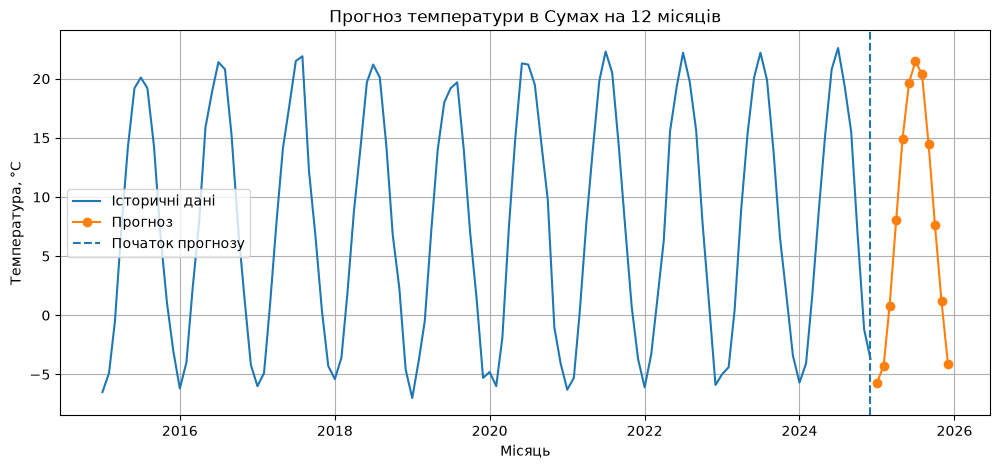

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    climate_ts.index,
    climate_ts.values,
    label="Історичні дані"
)

ax.plot(
    forecast.index,
    forecast.values,
    marker="o",
    label="Прогноз"
)

ax.axvline(
    climate_ts.index[-1],
    linestyle="--",
    label="Початок прогнозу"
)

ax.set_xlabel("Місяць")
ax.set_ylabel("Температура, °C")
ax.set_title("Прогноз температури в Сумах на 12 місяців")
ax.legend()
ax.grid(True)

plt.show()

### Застереження щодо прогнозу

Отриманий прогноз є екстраполяцією виявленого тренду та сезонної
структури, а не точною передбачуваною температурою.

Модель припускає, що характер потепління залишатиметься приблизно
незмінним у майбутньому. У реальності на температуру можуть
впливати аномальні погодні умови, зміни клімату, атмосферні
процеси та інші фактори, яких немає в цій моделі.

Тому прогноз на 12 місяців слід розглядати як орієнтовну оцінку
заданого синтетичного ряду. Зі збільшенням горизонту прогнозування
невизначеність зростає, а довіряти простому продовженню лінійного
тренду стає дедалі складніше.

## Завдання 5. Реальний тренд чи шум?

Перевіримо, чи є оцінений тренд статистично підтвердженим.

Нульова гіпотеза:

H₀: істинний нахил тренду дорівнює нулю.

Альтернативна гіпотеза:

H₁: істинний нахил тренду відрізняється від нуля.

Використаємо рівень значущості α = 0.05.

In [10]:
alpha = 0.05

slope = fit.slope
stderr = fit.stderr
pvalue = fit.pvalue

ci_low = slope - 1.96 * stderr
ci_high = slope + 1.96 * stderr

print(f"slope = {slope:.6f}")
print(f"stderr = {stderr:.6f}")
print(f"p-value = {pvalue:.6g}")

print(
    f"95% ДІ для нахилу: "
    f"[{ci_low:.6f}; {ci_high:.6f}]"
)

if pvalue < alpha:
    print("\nH0 відхиляємо.")
    print("Тренд статистично значущий при α = 0.05.")
else:
    print("\nНемає підстав відхиляти H0.")
    print("Тренд статистично не підтверджений при α = 0.05.")

slope = 0.002967
stderr = 0.000924
p-value = 0.00175388
95% ДІ для нахилу: [0.001156; 0.004779]

H0 відхиляємо.
Тренд статистично значущий при α = 0.05.


In [11]:
short_trend = decomposition.trend.dropna().iloc[-36:]

x_short = np.arange(len(short_trend))

fit_short = linregress(
    x_short,
    short_trend.values
)

print("=== Останні 3 роки ===")
print(f"slope = {fit_short.slope:.6f} °C/місяць")
print(f"slope за рік = {fit_short.slope * 12:.6f} °C/рік")
print(f"p-value = {fit_short.pvalue:.6g}")
print(f"stderr = {fit_short.stderr:.6f}")

=== Останні 3 роки ===
slope = 0.009788 °C/місяць
slope за рік = 0.117458 °C/рік
p-value = 2.72894e-08
stderr = 0.001365


### Статистичний висновок

Для оцінювання наявності тренду недостатньо лише перевірити,
чи є `slope` додатним. Додатний нахил може виникнути випадково
через шум у даних.

Основним критерієм є `p-value`. Якщо `p-value < 0.05`, нульову
гіпотезу про нульовий нахил відхиляємо та маємо статистичні підстави
вважати тренд відмінним від нуля.

95% довірчий інтервал для нахилу додатково показує діапазон
правдоподібних значень істинного нахилу. Якщо цей інтервал не
містить нуль, це узгоджується зі статистично значущим трендом
при рівні значущості 0.05.

Оцінка нахилу на останніх трьох роках може відрізнятися від оцінки
за всім десятирічним рядом. На коротшому інтервалі випадковий шум
має більший вплив на оцінений нахил, тому коротке вікно є менш
надійним для встановлення довгострокового тренду.

## Контрольні питання

### 1. Чому часовий ряд не можна повністю аналізувати як звичайну незалежну вибірку?

Тому що спостереження часового ряду впорядковані в часі та можуть
бути залежними між собою. Значення сусідніх місяців часто пов'язані,
а також можуть містити тренд і сезонність. Це порушує припущення
про незалежність спостережень.

### 2. Чому занадто мале вікно ковзного середнього є проблемою?

Мале вікно добре зберігає короткострокову структуру, але недостатньо
сильно прибирає шум і сезонні коливання.

### 3. Чому занадто велике вікно також є проблемою?

Велике вікно сильно згладжує ряд і може приховати важливі зміни.
Тому розмір вікна потрібно узгоджувати з періодом сезонності.

### 4. Чим відрізняються `center=False` та `center=True`?

При `center=False` використовуються поточне та попередні значення,
тому середнє має часовий лаг.

При `center=True` вікно симетрично охоплює значення до і після
поточного моменту. Такий підхід краще центрує згладжування, але
потребує майбутніх даних.

### 5. Чому одного додатного `slope` недостатньо?

Додатний нахил може бути результатом випадкового шуму. Для
статистичного підтвердження тренду потрібно аналізувати `p-value`
та довірчий інтервал.

### 6. Що означає `p-value < 0.05`?

При рівні значущості α = 0.05 це дає підстави відхилити нульову
гіпотезу про нульовий нахил тренду.

### 7. Що показує 95% довірчий інтервал для slope?

Він задає діапазон правдоподібних значень істинного нахилу тренду.
Якщо він не містить нуль, це узгоджується зі статистично значущим
трендом.

### 8. Чому прогноз за межами історичних даних ненадійний?

Тому що прогноз є екстраполяцією припущень моделі. Реальні умови
можуть змінити тренд, сезонність або рівень шуму, а проста модель
цього не враховує.